In [37]:
import pandas as pd
import numpy as np
import logging
import os
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union, List, Tuple, Optional
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [38]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [39]:
def load_raw_data(paths: Union[str, List[str]]) -> Union[pd.DataFrame, Tuple[pd.DataFrame, ...]]:
    """
    Reads CSV files from the provided paths.
    
    Args:
        paths: A single file path (str) or a list of file paths.
        
    Returns:
        A single DataFrame if one path is provided, 
        or a tuple of DataFrames if multiple paths are provided.
    """
    if isinstance(paths, str):
        paths = [paths]
        
    loaded_dfs = []
    
    for path in paths:
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            raise FileNotFoundError(f"The path {path} does not exist.")
            
        logger.info(f"Loading data from: {path}")
        df = pd.read_csv(path)
        logger.info(f"Successfully loaded {path} with shape: {df.shape}")
        loaded_dfs.append(df)
        
    return loaded_dfs[0] if len(loaded_dfs) == 1 else tuple(loaded_dfs)

In [40]:
def reduce_memory_usage(df: pd.DataFrame, file_name: str = "DataFrame") -> pd.DataFrame:
    """
    Downcasts numeric columns in a single DataFrame to save memory.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    logger.info(f"Memory optimization started for {file_name}. Initial: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype
        
        if pd.api.types.is_numeric_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            
            if "int" in str(col_type):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    logger.info(f"Optimization finished for {file_name}. Final: {end_mem:.2f} MB")
    return df

In [41]:
def extract_titles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts titles (Mr, Mrs, Miss, etc.) from the Name column.
    """
    logger.info("Extracting titles from Name column...")
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Consolidate rare titles to reduce noise/overfitting
    rare_titles = ['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    return df

In [42]:
def drop_redundant_columns(df: pd.DataFrame, columns_to_drop: List[str]) -> pd.DataFrame:
    """
    Removes specified columns from the DataFrame to prevent overfitting.
    """
    logger.info(f"Dropping columns: {columns_to_drop}")
    # Only drop if the column actually exists in the dataframe
    existing_cols = [c for c in columns_to_drop if c in df.columns]
    return df.drop(columns=existing_cols)

In [43]:
def impute_missing_ages(df: pd.DataFrame, n_neighbors: int = 5) -> pd.DataFrame:
    """
    Imputes missing Age values using KNN based on Pclass and Title.
    
    Args:
        df: The DataFrame containing Age, Pclass, and Title.
        n_neighbors: Number of neighboring samples to use for imputation.
        
    Returns:
        DataFrame with Age column filled.
    """
    logger.info(f"Starting KNN Imputation for Age using {n_neighbors} neighbors...")
    
    # 1. We need a temporary copy for the imputer to work with numbers
    impute_data = df[['Age', 'Pclass', 'Title']].copy()
    
    # 2. Encode Title to numeric for math operations
    encoder = OrdinalEncoder()
    impute_data['Title'] = encoder.fit_transform(impute_data[['Title']])
    
    # 3. Initialize and run KNN
    # We include Pclass because age distribution varies significantly by class
    imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_array = imputer.fit_transform(impute_data)
    
    # 4. Fill the original dataframe with the result
    # The first column [:, 0] of the result is the imputed Age
    df['Age'] = imputed_array[:, 0]
    
    logger.info("Age imputation complete.")
    return df

In [44]:
def bin_age_feature(df: pd.DataFrame, bins: Optional[List[int]] = None, labels: Optional[List[str]] = None) -> pd.DataFrame:
    """
    Groups continuous Age values into discrete categories (bins).
    
    Args:
        df: DataFrame containing the 'Age' column.
        bins: List of edge values for bins. Defaults to Titanic standard brackets.
        labels: Names for the bins.
        
    Returns:
        DataFrame with a new 'AgeGroup' column and dropped 'Age'.
    """
    logger.info("Starting Age binning process...")
    
    # Define default Titanic age brackets if none provided
    if bins is None:
        # 0-12: Child, 12-18: Teen, 18-35: Young Adult, 35-60: Adult, 60-100: Senior
        bins = [0, 12, 18, 35, 60, 100]
    if labels is None:
        labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

    try:
        # Create the AgeGroup feature
        df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
        
        # After binning, the original Age column with the 'spike' is often redundant
        # We drop it to prevent the model from over-focusing on the 32.80 value
        df = df.drop(columns=['Age'])
        
        logger.info(f"Age successfully binned into {len(labels)} categories.")
    except Exception as e:
        logger.error(f"Failed to bin Age: {e}")
        raise

    return df

In [45]:
def process_cabin_to_deck(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts the Deck letter from Cabin and handles missing values.
    Missing values are filled with 'U' (Unknown).
    """
    logger.info("Processing Cabin column into Decks...")
    
    # 1. Fill NaN with 'U' for Unknown
    df['Cabin'] = df['Cabin'].fillna('U')
    
    # 2. Extract the first letter (The Deck)
    # Example: 'C123' becomes 'C', 'U' stays 'U'
    df['Deck'] = df['Cabin'].apply(lambda x: x[0])
    
    # 3. Consolidate very rare decks to avoid overfitting
    # T deck is a single passenger; G and F are very small.
    # We can group them or leave them, but 'U' is the most important.
    df['Deck'] = df['Deck'].replace(['T'], 'U') 
    
    # 4. Drop the original messy Cabin column
    df = df.drop(columns=['Cabin'])
    
    logger.info(f"Deck extraction complete. Unique values: {df['Deck'].unique().tolist()}")
    return df

In [46]:
def final_imputation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Handles the final small missing values for Embarked and Fare.
    Uses Mode for Embarked and Pclass-Median for Fare.
    """
    logger.info("Starting final cleanup imputation...")

    # 1. Fill Embarked with the most common port ('S')
    if df['Embarked'].isnull().any():
        most_common_port = df['Embarked'].mode()[0]
        logger.info(f"Filling missing Embarked with mode: {most_common_port}")
        df['Embarked'] = df['Embarked'].fillna(most_common_port)

    # 2. Fill Fare with the median of its Pclass
    if df['Fare'].isnull().any():
        logger.info("Filling missing Fare with Pclass median.")
        # This groups by Pclass and fills the missing Fare in each group with its median
        df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

    logger.info("Final imputation complete.")
    return df

In [47]:
def process_fare_features(df: pd.DataFrame, n_bins: int = 4) -> pd.DataFrame:
    """
    Handles Fare outliers using Log Transformation and Quantile Binning.
    
    Args:
        df: DataFrame containing 'Fare'.
        n_bins: Number of equal-sized buckets for binning.
        
    Returns:
        DataFrame with Log_Fare and FareGroup, dropping original Fare.
    """
    logger.info(f"Processing Fare: applying Log1p and {n_bins}-quantile binning.")
    
    try:
        # 1. Log Transform: handles the skewness mathematically
        # we use log1p (log of 1+x) to avoid errors with $0 fares
        df['Log_Fare'] = df['Fare'].apply(np.log1p)
        
        # 2. Quantile Binning: groups into equal-sized buckets (Cheap, Mid, High, Luxury)
        # 'labels=False' returns 0, 1, 2, 3...
        df['FareGroup'] = pd.qcut(df['Fare'], n_bins, labels=False)
        
        # 3. Drop original Fare to remove the raw outliers
        df = df.drop(columns=['Fare'])
        
        logger.info("Fare features created: 'Log_Fare' and 'FareGroup'.")
    except Exception as e:
        logger.error(f"Error processing Fare outliers: {e}")
        raise

    return df

In [48]:
def create_family_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Creates FamilySize and groups it into categories: Alone, Small, and Large.
    
    Logic:
        Alone: 1 person
        Small: 2-4 people
        Large: 5+ people
    """
    logger.info("Creating Family-based features...")
    
    if 'SibSp' in df.columns and 'Parch' in df.columns:
        # Calculate raw size (Passenger + Siblings/Spouse + Parents/Children)
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        
        # Binary flags for different family dynamics
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
        df['SmallFam'] = ((df['FamilySize'] > 1) & (df['FamilySize'] < 5)).astype(int)
        df['LargeFam'] = (df['FamilySize'] >= 5).astype(int)
        
        logger.info(f"Family features created. Alone: {df['IsAlone'].sum()}, "
                    f"Small: {df['SmallFam'].sum()}, Large: {df['LargeFam'].sum()}")
    else:
        logger.warning("SibSp or Parch columns missing. Skipping Family features.")
        
    return df

In [49]:
def encode_categorical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encodes categorical features into numeric formats.
    """
    logger.info("Starting categorical encoding...")

    # 1. Binary Encode Sex
    if 'Sex' in df.columns:
        logger.info("Encoding Sex as binary.")
        df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}).astype(int)

    # 2. One-Hot Encode Port
    if 'Embarked' in df.columns:
        logger.info("One-Hot Encoding Embarked.")
        df = pd.get_dummies(df, columns=['Embarked'], prefix='Port', drop_first=True, dtype=int)
    
    # 3. One-Hot Encode Title
    if 'Title' in df.columns:
        logger.info("One-Hot Encoding Title.")
        df = pd.get_dummies(df, columns=['Title'], prefix='Title', drop_first=True, dtype=int)

    # 4. One-Hot Encode AgeGroup
    if 'AgeGroup' in df.columns:
        logger.info("One-Hot Encoding AgeGroup.")
        df = pd.get_dummies(df, columns=['AgeGroup'], prefix='Age', drop_first=True, dtype=int)
        
    # 5. One-Hot Encode Deck
    if 'Deck' in df.columns:
        logger.info("One-Hot Encoding Deck.")
        df = pd.get_dummies(df, columns=['Deck'], prefix='Deck', drop_first=True, dtype=int)

    # 6. One-Hot Encode FareGroup (Optional but recommended for consistency)
    if 'FareGroup' in df.columns:
        logger.info("One-Hot Encoding FareGroup.")
        df = pd.get_dummies(df, columns=['FareGroup'], prefix='Fare', drop_first=True, dtype=int)

    logger.info(f"Encoding complete. Columns: {len(df.columns)}")
    return df

In [50]:
def finalize_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Handles indexing and drops columns that are no longer needed for modeling.
    """
    logger.info("Finalizing dataframe: dropping redundant columns and setting index.")

    if 'PassengerId' in df.columns:
        df = df.set_index('PassengerId')

    cols_to_drop = ['Name', 'Ticket', 'SibSp', 'Parch', 'FamilySize']
    
    existing_drops = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=existing_drops)
    
    logger.info(f"Final columns remaining: {df.columns.tolist()}")
    return df

In [51]:
def run_feature_engineering_pipeline(file_path: str) -> pd.DataFrame:
    """
    Orchestrates the full feature engineering process from raw CSV to model-ready DataFrame.
    
    Args:
        file_path: Path to the raw data CSV file.
        
    Returns:
        A processed pandas DataFrame ready for training or inference.
    """
    logger.info(f"--- Starting Pipeline for {file_path} ---")
    
    try:
        # 1. Data Ingestion & Optimization
        df = load_raw_data(file_path)
        df = reduce_memory_usage(df, file_name=file_path)

        # 2. Text Extraction & Imputation
        # Titles must come first as they help the Age Imputer
        df = extract_titles(df)
        df = impute_missing_ages(df)
        
        # 3. Handling Missingness & Structural Changes
        df = bin_age_feature(df)
        df = final_imputation(df) # Handles Embarked/Fare missing values
        df = process_cabin_to_deck(df)
        
        # 4. Feature Scaling & Mathematical Transforms
        df = process_fare_features(df)
        
        df = create_family_features(df)
        # 5. Categorical Encoding
        df = encode_categorical_features(df)
        
        # 6. Final Pruning & Indexing
        df = finalize_features(df)
        
        logger.info(f"--- Pipeline Completed Successfully. Final Shape: {df.shape} ---")
        return df

    except Exception as e:
        logger.error(f"Pipeline failed at a processing step: {e}", exc_info=True)
        raise

In [52]:
df = run_feature_engineering_pipeline('data/train.csv')


2026-03-13 16:07:45,398 - INFO - --- Starting Pipeline for data/train.csv ---
2026-03-13 16:07:45,399 - INFO - Loading data from: data/train.csv
2026-03-13 16:07:45,404 - INFO - Successfully loaded data/train.csv with shape: (891, 12)
2026-03-13 16:07:45,406 - INFO - Memory optimization started for data/train.csv. Initial: 0.31 MB
2026-03-13 16:07:45,409 - INFO - Optimization finished for data/train.csv. Final: 0.27 MB
2026-03-13 16:07:45,409 - INFO - Extracting titles from Name column...
2026-03-13 16:07:45,412 - INFO - Starting KNN Imputation for Age using 5 neighbors...
2026-03-13 16:07:45,418 - INFO - Age imputation complete.
2026-03-13 16:07:45,418 - INFO - Starting Age binning process...
2026-03-13 16:07:45,419 - INFO - Age successfully binned into 5 categories.
2026-03-13 16:07:45,420 - INFO - Starting final cleanup imputation...
2026-03-13 16:07:45,420 - INFO - Filling missing Embarked with mode: S
2026-03-13 16:07:45,420 - INFO - Final imputation complete.
2026-03-13 16:07:45,

In [53]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Log_Fare', 'IsAlone', 'SmallFam',
       'LargeFam', 'Port_Q', 'Port_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Rare', 'Age_Teen', 'Age_Young Adult', 'Age_Adult', 'Age_Senior',
       'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_U',
       'Fare_1', 'Fare_2', 'Fare_3'],
      dtype='str')

In [62]:
def train_and_tune_models(X, y):
    """
    Trains RandomForest, GradientBoosting, and LogisticRegression using GridSearchCV.
    """
    
    models = {
        'RandomForest': {
            'model': RandomForestClassifier(random_state=42),
            'params': {
                'classifier__n_estimators': [50 , 100, 200],
                'classifier__max_depth': [5, 8, 12],
                'classifier__min_samples_leaf': [1, 2, 4]
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {
                'classifier__n_estimators': [50, 100, 150],
                'classifier__learning_rate': [0.01, 0.05, 0.1, 0.12, 0.15],
                'classifier__max_depth': [3, 4, 5]
            }
        },
        'LogisticRegression': {
            'model': LogisticRegression(max_iter=1000, random_state=42),
            'params': {
                'classifier__C': [0.1, 1, 10], # Regularization strength
                'classifier__solver': ['liblinear', 'lbfgs']
            }
        }
    }

    best_models = {}

    for name, config in models.items():
        logger.info(f"Starting Grid Search for {name}...")
        
        # We MUST use the Scaler for Logistic Regression!
        pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('classifier', config['model'])
        ])
        
        grid = GridSearchCV(pipeline, config['params'], cv=5, scoring='accuracy', n_jobs=-1)
        grid.fit(X, y)
        
        logger.info(f"Best {name} Score: {grid.best_score_:.4f}")
        best_models[name] = grid.best_estimator_

    return best_models

In [63]:
df_train = run_feature_engineering_pipeline('data/train.csv')

X = df_train.drop('Survived', axis=1)
y = df_train['Survived']


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

best_models = train_and_tune_models(X_train, y_train)

for name, model in best_models.items():
    val_preds = model.predict(X_val)
    score = accuracy_score(y_val, val_preds)
    print(f"{name} Validation Accuracy: {score:.4f}")

2026-03-13 16:18:27,166 - INFO - --- Starting Pipeline for data/train.csv ---
2026-03-13 16:18:27,168 - INFO - Loading data from: data/train.csv
2026-03-13 16:18:27,177 - INFO - Successfully loaded data/train.csv with shape: (891, 12)
2026-03-13 16:18:27,181 - INFO - Memory optimization started for data/train.csv. Initial: 0.31 MB
2026-03-13 16:18:27,187 - INFO - Optimization finished for data/train.csv. Final: 0.27 MB
2026-03-13 16:18:27,188 - INFO - Extracting titles from Name column...
2026-03-13 16:18:27,194 - INFO - Starting KNN Imputation for Age using 5 neighbors...
2026-03-13 16:18:27,208 - INFO - Age imputation complete.
2026-03-13 16:18:27,208 - INFO - Starting Age binning process...
2026-03-13 16:18:27,210 - INFO - Age successfully binned into 5 categories.
2026-03-13 16:18:27,211 - INFO - Starting final cleanup imputation...
2026-03-13 16:18:27,211 - INFO - Filling missing Embarked with mode: S
2026-03-13 16:18:27,212 - INFO - Final imputation complete.
2026-03-13 16:18:27,

RandomForest Validation Accuracy: 0.8268
GradientBoosting Validation Accuracy: 0.8324
LogisticRegression Validation Accuracy: 0.8101


/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_57228/2069905324.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')


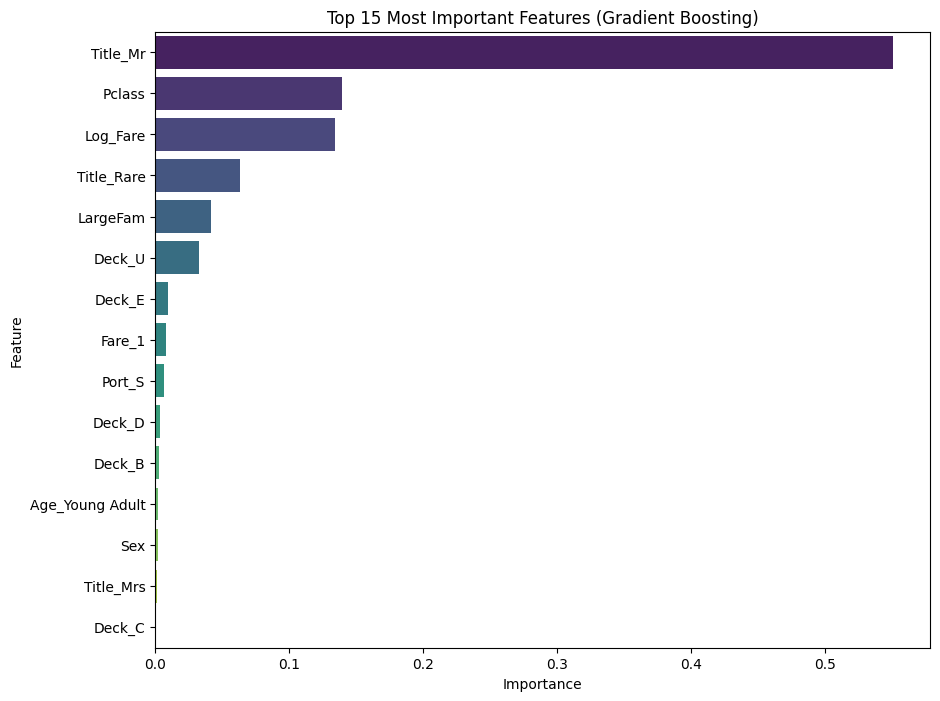

In [64]:
best_gb = best_models['GradientBoosting'].named_steps['classifier']
features = X_train.columns
importances = best_gb.feature_importances_

# Create a DataFrame for visualization
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')
plt.title('Top 15 Most Important Features (Gradient Boosting)')
plt.show()

In [65]:
from sklearn.ensemble import VotingClassifier

# Create the ensemble using the best versions of each model
ensemble_model = VotingClassifier(
    estimators=[
        ('gb', best_models['GradientBoosting']),
        ('rf', best_models['RandomForest']),
        ('lr', best_models['LogisticRegression'])
    ],
    voting='soft' # Uses the probabilities to decide
)

# Fit on the training data
ensemble_model.fit(X_train, y_train)

# Final Validation Score
ensemble_score = ensemble_model.score(X_val, y_val)
print(f"Ensemble Validation Accuracy: {ensemble_score:.4f}")

Ensemble Validation Accuracy: 0.8380


In [61]:
from sklearn.model_selection import cross_val_score

# Use the best pipeline found by GridSearch
pipeline = best_models['GradientBoosting']
cv_scores = cross_val_score(pipeline, X, y, cv=10)

print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Mean CV Accuracy: 0.8272
Standard Deviation: 0.0447


In [60]:
df_test_processed = run_feature_engineering_pipeline('data/test.csv')

# 2. Ensure columns match the training data
# (If a title or deck existed in train but not test, we need to handle that)
X_test = df_test_processed.reindex(columns=X.columns, fill_value=0)

# 3. Predict using the Ensemble
final_predictions = ensemble_model.predict(X_test)

# 4. Create the submission file
submission = pd.DataFrame({
    "PassengerId": df_test_processed.index,
    "Survived": final_predictions
})

submission.to_csv('data/submission.csv', index=False)
logger.info("Submission file 'submission.csv' created successfully!")

2026-03-13 16:12:58,876 - INFO - --- Starting Pipeline for data/test.csv ---
2026-03-13 16:12:58,878 - INFO - Loading data from: data/test.csv
2026-03-13 16:12:58,883 - INFO - Successfully loaded data/test.csv with shape: (418, 11)
2026-03-13 16:12:58,886 - INFO - Memory optimization started for data/test.csv. Initial: 0.14 MB
2026-03-13 16:12:58,891 - INFO - Optimization finished for data/test.csv. Final: 0.13 MB
2026-03-13 16:12:58,892 - INFO - Extracting titles from Name column...
2026-03-13 16:12:58,897 - INFO - Starting KNN Imputation for Age using 5 neighbors...
2026-03-13 16:12:58,907 - INFO - Age imputation complete.
2026-03-13 16:12:58,908 - INFO - Starting Age binning process...
2026-03-13 16:12:58,910 - INFO - Age successfully binned into 5 categories.
2026-03-13 16:12:58,910 - INFO - Starting final cleanup imputation...
2026-03-13 16:12:58,912 - INFO - Filling missing Fare with Pclass median.
2026-03-13 16:12:58,915 - INFO - Final imputation complete.
2026-03-13 16:12:58,91